# Quantum Gibbs sampler — run notebook

This notebook only *runs* the code. All function and class definitions live in `definitions.py` (same folder) and are imported below.

- Three Lindbladian constructions: time domain, frequency domain, and Anthony's construction.
- Sanity checks that all three constructions agree.
- A convergence-time sweep over `sigma` and `beta`, with comparison plots.

## Imports

Pull in everything from `definitions.py`.

In [29]:
from __future__ import annotations
import sys
import time
import itertools
import random
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh, expm

sys.path.append('..')
from gibbs_state_prep.helpers import ising_1d, heisenberg_1d, compute_trace_distance, I, X, Y, Z, kron, kron_n
from gibbs_state_prep.algorithm.preparation import IntegrationGrid
from gibbs_state_prep.exact.gibbs_state import GibbsState

from ROBERTS_sampler.definitions import *

# Parameters

In [30]:
number_of_spins = 3
J = 1
h = 0.3

## Build the local Z jump operators

In [31]:
coupling_ops = normalized_simple_jumps(number_of_spins)

## Sanity check: fast linear-algebra helpers

Checks the vectorized NumPy replacements for the old qutip operations against brute-force reference implementations on random operators.

In [32]:
validate_fast_linear_algebra()

All fast linear-algebra identities match their reference implementations.


## Check that all Lindbladian constructions satisfy DB and trace 0

Build the Hamiltonian, pick a random $\sigma$ and $\beta$, construct the Lindbladian with all three methods, and compare the $L^\dagger(I)=0$ / detailed-balance residuals plus the pairwise differences between constructions.

In [33]:
hamiltonian = ising_1d(n=number_of_spins, J= J ,h= h, periodic=True )

sigma_value = random.uniform(0,2)
beta_value = random.uniform(0,2)
S_value = 10

int_grid = IntegrationGrid(10,10201)

print("The random sigma is = ", sigma_value)
print("The random beta is = ", beta_value)
print('')

eig_cache_single: Dict = {}
lindbladians = {}
gibbs_states = {}
d = hamiltonian.shape[0]

for name, builder in LINDBLADIANS.items():
    if name == "BA":
        continue
    Lind, rho_g = builder(hamiltonian, beta_value, sigma_value, S_value, int_grid, coupling_ops,
                           q_filter="gaussian", eig_cache=eig_cache_single)
    lindbladians[name] = Lind
    gibbs_states[name] = rho_g
    print(f"[{name}]")
    print(f"  max|L^dagger(I)|          = {l_dagger_identity_residual(Lind, d):.3e}")
    print(f"  detailed-balance residual = {detailed_balance_residual(Lind, rho_g):.3e}")

print('')
BA_builder = LINDBLADIANS["BA"]

for ba_gamma_filter in GAMMAS_BA:
    try:
        Lind_BA, rho_g_BA = BA_builder(hamiltonian, beta_value, sigma_value, S_value, int_grid, coupling_ops,
                                        q_filter=ba_gamma_filter, eig_cache=eig_cache_single)
    except ValueError:
        print(f"[L_BA, transition rate gamma(w): {ba_gamma_filter}]  skipped: sigma_value={sigma_value:.3g} is out of the "
              f"valid range for this rate at beta_value={beta_value:.3g}")
        continue
    print(f"[L_BA, ransition rate gamma(w): {ba_gamma_filter}]")
    print(f"  max|L^dagger(I)|          = {l_dagger_identity_residual(Lind_BA, d):.3e}")
    print(f"  detailed-balance residual = {detailed_balance_residual(Lind_BA, rho_g_BA):.3e}")


The random sigma is =  1.203542613688576
The random beta is =  1.092176290730069



/Users/lorisweber/Desktop/Roberts_Gibbs_sampler/ROBERTS_sampler/../ROBERTS_sampler/definitions.py:408: RuntimeWarning: overflow encountered in exp
  return np.exp(-nu**2 / (8 * sigma**2)) / (1 + np.exp(beta * nu / 2))


[L_R_time_domain]
  max|L^dagger(I)|          = 8.479e-14
  detailed-balance residual = 2.283e-08
[L_R_frequency_domain]
  max|L^dagger(I)|          = 2.439e-15
  detailed-balance residual = 9.025e-13
[L_R_anthony_time_construction]
  max|L^dagger(I)|          = 2.770e-14
  detailed-balance residual = 2.283e-08
[L_R_anthony_frequency_construction]
  max|L^dagger(I)|          = 2.200e-14
  detailed-balance residual = 9.026e-13

[L_BA, ransition rate gamma(w): metropolis]
  max|L^dagger(I)|          = 4.342e-19
  detailed-balance residual = 7.017e-07
[L_BA, ransition rate gamma(w): gaussian]
  max|L^dagger(I)|          = 1.427e-19
  detailed-balance residual = 1.396e-16


## Convergence-time sweep for Roberts Lindbladian L_R with frequency domain constr. and Anthony frequency domain constr.

Runs the sweep across every construction, sigma, and beta combination and records the convergence time plus the two structural diagnostics (L^dagger(I) residual, detailed-balance residual).

In [34]:
sigma_values = np.linspace(0.1,4,10)
#beta_values = np.linspace(1e-3,1e-2, 5)
beta_values = np.linspace(0.2,1,4)

q_filter_ = 'gaussian'
threshold_value = 1e-2
max_evo_time = 1e8
method_for_evo = 'SPECTRAL' #RK4 much slower then 'SPECTRAL'

results_df = run_convergence_sweep(
    hamiltonian, sigma_values, beta_values, grid_with_sigma_and_beta_dependency, S_value, coupling_ops,
    constructions= ( "L_R_frequency_domain", "L_R_anthony_frequency_construction"),
    q_filter=q_filter_, threshold= threshold_value, max_time=max_evo_time, method=method_for_evo)

n_invalid = (~results_df["valid_generator"]).sum()
print(f"{n_invalid} / {len(results_df)} grid points have an invalid generator "
      f"(failed L^dagger(I)=0 or detailed balance), broken down by construction:")
print(results_df.groupby("construction")["valid_generator"].agg(lambda s: (~s).sum()))

results_df

[1/80] L_R_frequency_domain sigma=0.1 beta=0.2 -> t_conv=74.7231  L+_res=9.99e-16  DB_res=1.69e-13  spectral_gap 0.033515 
[2/80] L_R_frequency_domain sigma=0.1 beta=0.4667 -> t_conv=115.994  L+_res=9.38e-16  DB_res=3.38e-13  spectral_gap 0.025995 
[3/80] L_R_frequency_domain sigma=0.1 beta=0.7333 -> t_conv=249.507  L+_res=8.31e-16  DB_res=4.98e-13  spectral_gap 0.012644 
[4/80] L_R_frequency_domain sigma=0.1 beta=1 -> t_conv=822.598  L+_res=1.03e-15  DB_res=6.37e-13  spectral_gap 0.003888 
[5/80] L_R_frequency_domain sigma=0.5333 beta=0.2 -> t_conv=74.7237  L+_res=2.03e-15  DB_res=2.08e-13  spectral_gap 0.029706 
[6/80] L_R_frequency_domain sigma=0.5333 beta=0.4667 -> t_conv=115.995  L+_res=2.90e-15  DB_res=4.36e-13  spectral_gap 0.025437 
[7/80] L_R_frequency_domain sigma=0.5333 beta=0.7333 -> t_conv=249.508  L+_res=1.47e-15  DB_res=6.44e-13  spectral_gap 0.012644 
[8/80] L_R_frequency_domain sigma=0.5333 beta=1 -> t_conv=822.603  L+_res=1.74e-15  DB_res=8.19e-13  spectral_gap 0.0038

,construction,sigma,beta,convergence_time,wall_time_sec,converged,l_dagger_id_residual,detailed_balance_residual,valid_generator,spectral_gap
0,L_R_frequency_domain,0.100000,0.200000,74.723090,0.081691,True,9.992007e-16,1.685252e-13,True,0.033515
1,L_R_frequency_domain,0.100000,0.466667,115.993778,0.073475,True,9.380517e-16,3.375021e-13,True,0.025995
2,L_R_frequency_domain,0.100000,0.733333,249.506526,0.071931,True,8.313662e-16,4.978537e-13,True,0.012644
3,L_R_frequency_domain,0.100000,1.000000,822.597886,0.071436,True,1.034763e-15,6.372587e-13,True,0.003888
4,L_R_frequency_domain,0.533333,0.200000,74.723672,0.061218,True,2.034831e-15,2.078859e-13,True,0.029706
...,...,...,...,...,...,...,...,...,...,...
75,L_R_anthony_frequency_construction,3.566667,1.000000,1282.883933,0.644022,True,2.256875e-15,8.567539e-13,True,0.002495
76,L_R_anthony_frequency_construction,4.000000,0.200000,303.100237,0.739517,True,2.011195e-15,2.237176e-13,True,0.003242
77,L_R_anthony_frequency_construction,4.000000,0.466667,327.768600,0.711435,True,2.575197e-15,4.636714e-13,True,0.003987
78,L_R_anthony_frequency_construction,4.000000,0.733333,507.743606,0.713218,True,1.535325e-15,6.765186e-13,True,0.006100


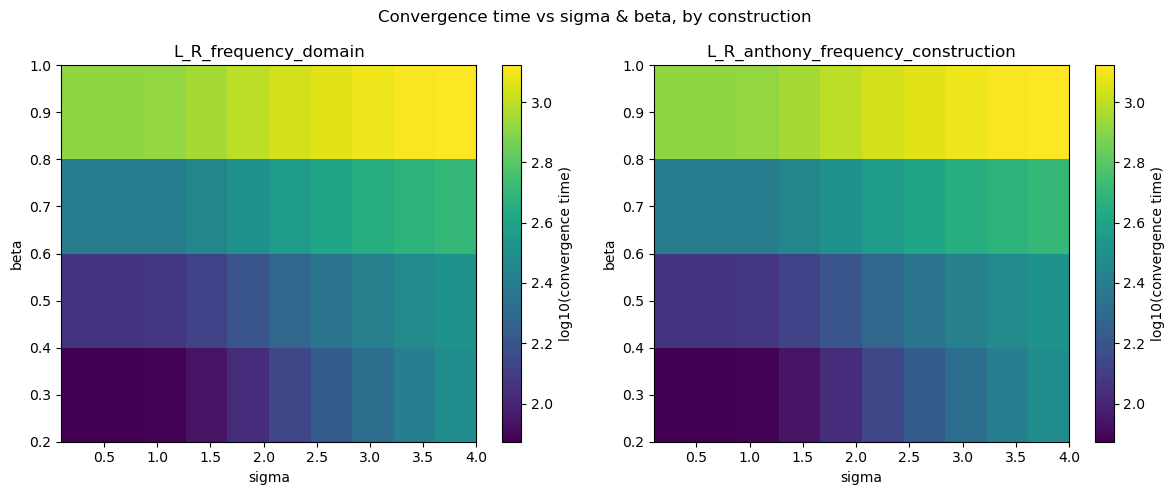

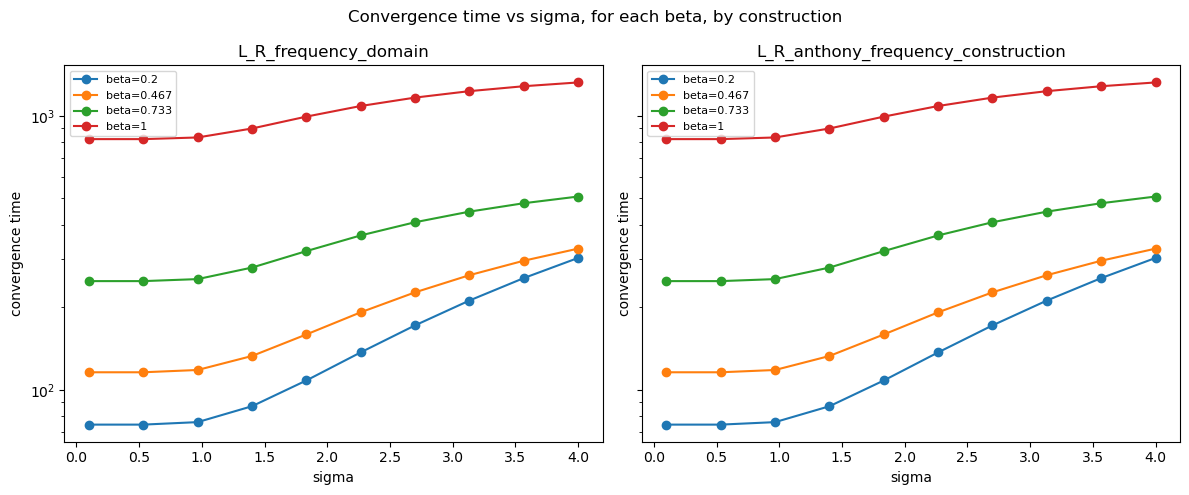

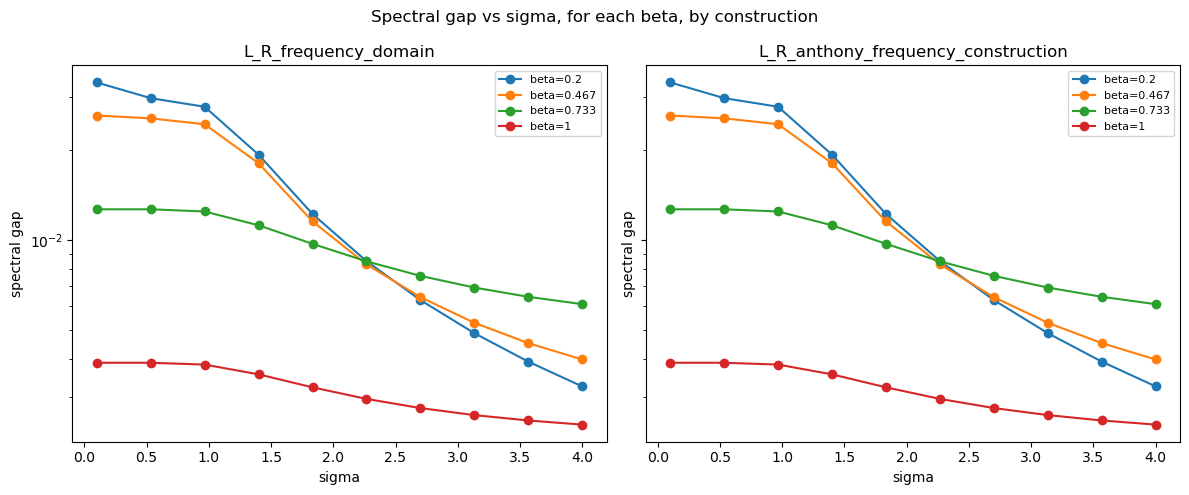

In [35]:
plot_convergence_heatmap(results_df)
plot_convergence_lines(results_df)
plot_spectral_gap_lines(results_df) 

## Convergence time and spectral gap multiplied with a HASTLE function

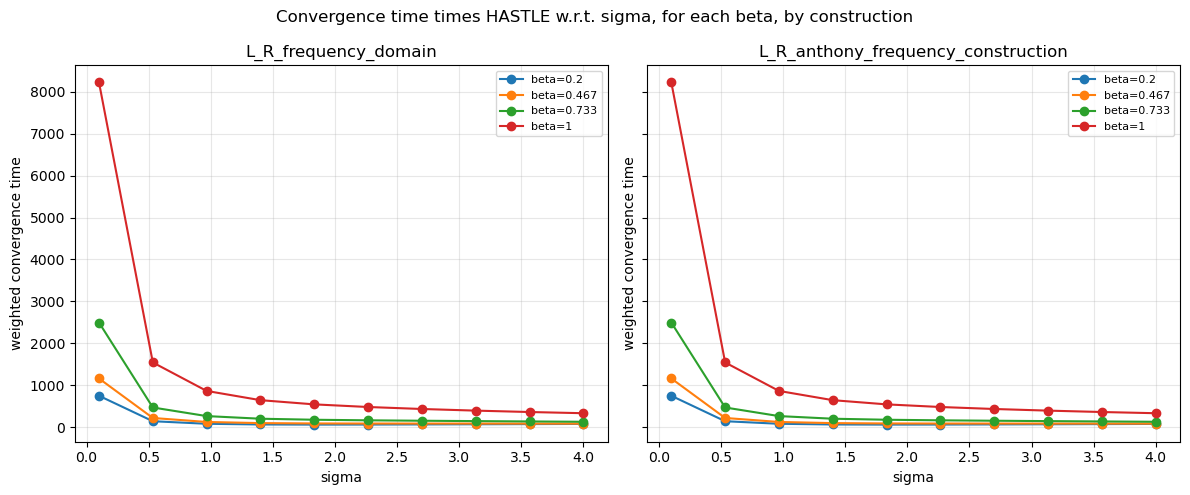

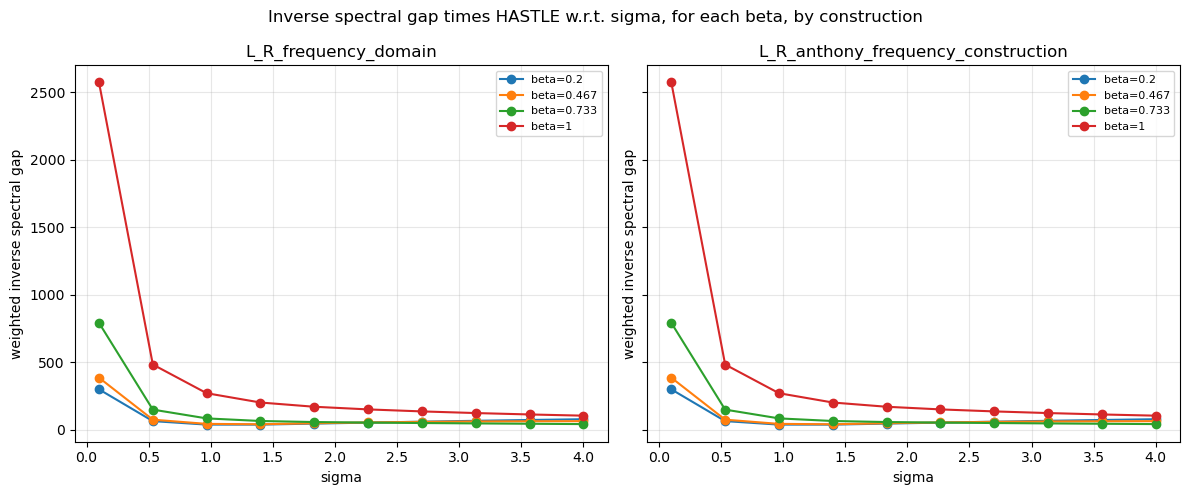

In [36]:
'''
Choices for the HASTLE function:    "inverse_sigma", "inverse_sigma_beta", "inverse_sigma_sq", "inverse_sigma_beta_sq", "constant"
'''

hastle_name = "inverse_sigma"  

conv_time_times_hastle = convergence_time_times_hastle(results_df, hastle_function=HASTLE_FUNCTIONS[hastle_name])
plot_convergence_time_times_hastle(conv_time_times_hastle)


gap_times_hastle = spectral_gap_times_hastle(results_df, hastle_function=HASTLE_FUNCTIONS[hastle_name])
plot_spectral_gap_times_hastle(gap_times_hastle)


# Lets compare both Lindbladians

In [37]:
filter_BA = 'metropolis'

results_BA = run_convergence_sweep(
    hamiltonian, sigma_values, beta_values, grid_with_sigma_and_beta_dependency, S_value, coupling_ops,
    constructions= ( "BA",),
    q_filter=filter_BA, threshold= threshold_value, max_time=max_evo_time, method=method_for_evo)

n_invalid = (~results_BA["valid_generator"]).sum()
print(f"{n_invalid} / {len(results_BA)} grid points have an invalid generator "
      f"(failed L^dagger(I)=0 or detailed balance), broken down by construction:")
print(results_BA.groupby("construction")["valid_generator"].agg(lambda s: (~s).sum()))

results_BA

[1/40] BA                sigma=0.1 beta=0.2 -> t_conv=18098.5  L+_res=2.04e-17  DB_res=8.23e-09  spectral_gap 0.000138 
[2/40] BA                sigma=0.1 beta=0.4667 -> t_conv=23818.8  L+_res=1.02e-17  DB_res=3.24e-08  spectral_gap 0.000127 
[3/40] BA                sigma=0.1 beta=0.7333 -> t_conv=25715  L+_res=2.86e-17  DB_res=6.23e-08  spectral_gap 0.000123 
[4/40] BA                sigma=0.1 beta=1 -> t_conv=26343.4  L+_res=2.43e-17  DB_res=8.84e-08  spectral_gap 0.000121 
[5/40] BA                sigma=0.5333 beta=0.2 -> t_conv=18098.9  L+_res=5.94e-17  DB_res=5.24e-09  spectral_gap 0.000123 
[6/40] BA                sigma=0.5333 beta=0.4667 -> t_conv=23819.6  L+_res=3.70e-17  DB_res=1.55e-08  spectral_gap 0.000123 
[7/40] BA                sigma=0.5333 beta=0.7333 -> t_conv=25715.7  L+_res=5.02e-17  DB_res=2.66e-08  spectral_gap 0.000123 
[8/40] BA                sigma=0.5333 beta=1 -> t_conv=26344  L+_res=4.19e-17  DB_res=6.58e-09  spectral_gap 0.000121 
[9/40] BA               

,construction,sigma,beta,convergence_time,wall_time_sec,converged,l_dagger_id_residual,detailed_balance_residual,valid_generator,spectral_gap
0,BA,0.100000,0.200000,1.809851e+04,0.182718,True,2.039655e-17,8.233319e-09,True,1.383597e-04
1,BA,0.100000,0.466667,2.381883e+04,0.157775,True,1.020166e-17,3.241321e-08,True,1.265911e-04
2,BA,0.100000,0.733333,2.571497e+04,0.161184,True,2.857550e-17,6.228881e-08,True,1.226920e-04
3,BA,0.100000,1.000000,2.634344e+04,0.170905,True,2.429290e-17,8.838162e-08,True,1.214199e-04
4,BA,0.533333,0.200000,1.809895e+04,0.154891,True,5.940411e-17,5.237794e-09,True,1.232022e-04
5,BA,0.533333,0.466667,2.381956e+04,0.150743,True,3.701068e-17,1.549920e-08,True,1.233946e-04
6,BA,0.533333,0.733333,2.571567e+04,0.154125,True,5.017908e-17,2.662001e-08,True,1.226894e-04
7,BA,0.533333,1.000000,2.634398e+04,0.151534,True,4.185020e-17,6.580590e-09,True,1.214180e-04
8,BA,0.966667,0.200000,2.384866e+04,0.209235,True,1.940722e-17,4.072257e-10,True,8.931580e-05
9,BA,0.966667,0.466667,3.135801e+04,0.214060,True,1.329244e-17,2.311127e-09,True,9.098130e-05


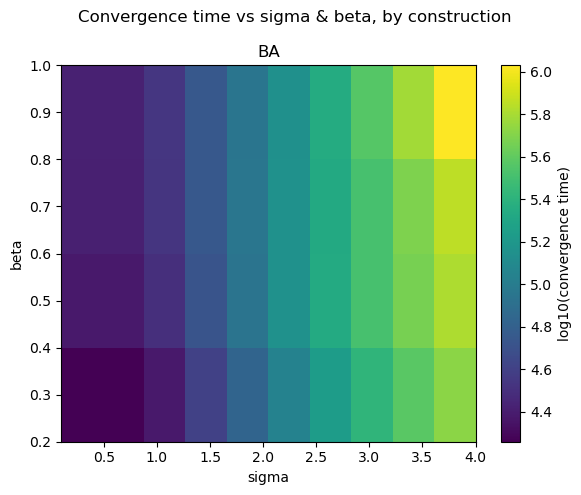

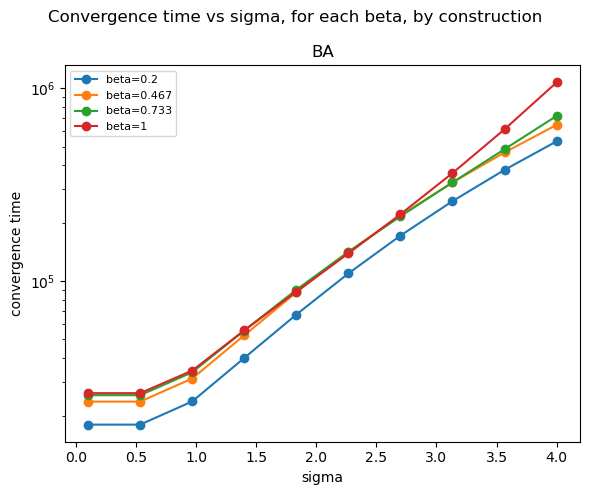

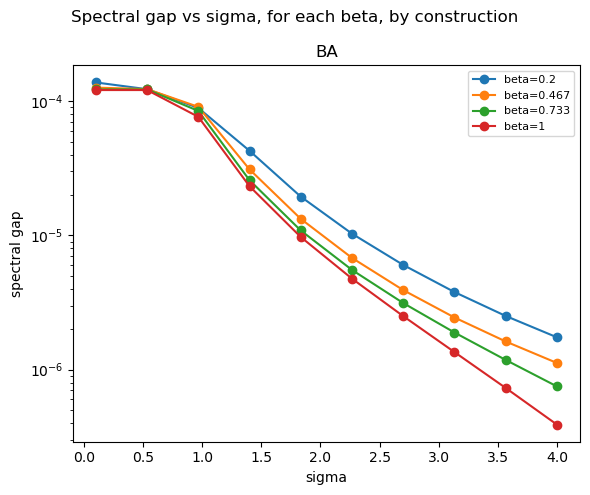

In [38]:
plot_convergence_heatmap(results_BA)
plot_convergence_lines(results_BA)
plot_spectral_gap_lines(results_BA)

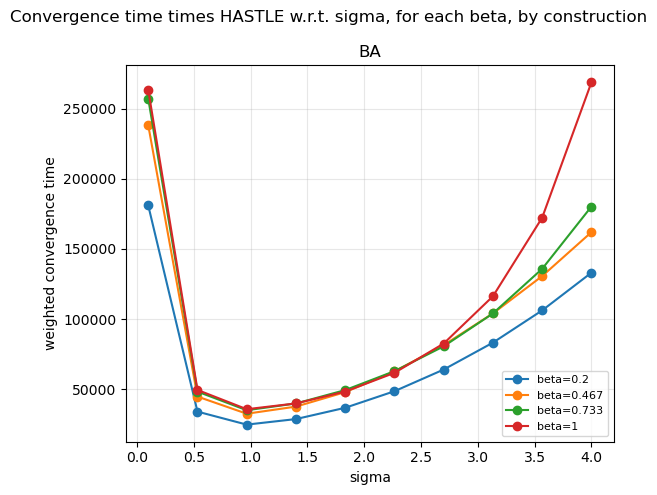

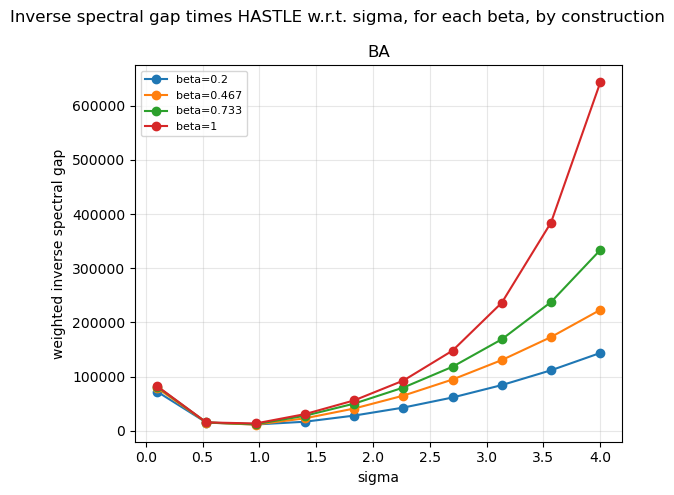

In [39]:
conv_time_times_hastle_L_BA = convergence_time_times_hastle(results_BA, hastle_function=HASTLE_FUNCTIONS[hastle_name])
plot_convergence_time_times_hastle(conv_time_times_hastle_L_BA)


gap_times_hastle_L_BA = spectral_gap_times_hastle(results_BA, hastle_function=HASTLE_FUNCTIONS[hastle_name])
plot_spectral_gap_times_hastle(gap_times_hastle_L_BA)

## Locate & refine the sigma minimum of the weighted convergence time

Same computation as the two cells above (`run_convergence_sweep` + `convergence_time_times_hastle`), but with a much denser sigma grid, followed by:
1. Finding the sigma that minimizes the weighted convergence time, per (construction, beta) -- if the argmin sits on the edge of the sigma grid, no interior minimum was found.
2. Zooming in: re-sweeping a finer sigma grid bracketing each coarse minimum to pin it down more precisely.

In [44]:
sigma_values_dense = np.linspace(0.1, 4, 60)  
beta_values_ = np.linspace(0.1,3.0,5)

minima_results = sweep_and_locate_sigma_minima(
    hamiltonian, sigma_values_dense, beta_values_, grid_with_sigma_and_beta_dependency, S_value, coupling_ops,
    constructions=("L_R_anthony_frequency_construction",),
    hastle_function=HASTLE_FUNCTIONS[hastle_name],
    n_sigma_fine=25,
    q_filter=q_filter_, threshold=threshold_value, max_time=max_evo_time, method=method_for_evo)


[1/300] L_R_anthony_frequency_construction sigma=0.1 beta=0.1 -> t_conv=58.5823  L+_res=9.30e-15  DB_res=9.59e-14  spectral_gap 0.032962 
[2/300] L_R_anthony_frequency_construction sigma=0.1 beta=0.825 -> t_conv=358.188  L+_res=5.87e-15  DB_res=5.48e-13  spectral_gap 0.008866 
[3/300] L_R_anthony_frequency_construction sigma=0.1 beta=1.55 -> t_conv=36442.3  L+_res=7.07e-15  DB_res=8.56e-13  spectral_gap 0.000088 
[4/300] L_R_anthony_frequency_construction sigma=0.1 beta=2.275 -> t_conv=1e+08  L+_res=5.26e-15  DB_res=1.05e-12  spectral_gap 0.000000  [NOT CONVERGED] 
[5/300] L_R_anthony_frequency_construction sigma=0.1 beta=3 -> t_conv=1e+08  L+_res=6.44e-15  DB_res=1.17e-12  spectral_gap 0.000000  [NOT CONVERGED] 
[6/300] L_R_anthony_frequency_construction sigma=0.1661 beta=0.1 -> t_conv=58.5823  L+_res=3.59e-15  DB_res=9.96e-14  spectral_gap 0.032962 


KeyboardInterrupt: 

Denser version of the weighted-convergence-time plot (more sigma points per line):

In [ ]:
plot_convergence_time_times_hastle(minima_results["coarse_weighted"], hastle_name=hastle_name)

Coarse-grid minimum sigma per construction and per beta:

In [ ]:
minima_results["minima_df"]

Refined minimum sigma (finer local grid around each coarse minimum found above):

In [ ]:
minima_results["refined_minima_df"]

Minimum weighted convergence time vs beta, one line per construction (only betas where an interior minimum was found are shown):

In [ ]:
plot_sigma_minima_vs_beta(minima_results["refined_minima_df"])


## Convergence-time sweep for time domain (separated since takes very long)

Runs the sweep across every construction, sigma, and beta combination and records the convergence time plus the two structural diagnostics (L^dagger(I) residual, detailed-balance residual).

In [ ]:
results_df_time_domain = run_convergence_sweep(
    hamiltonian, sigma_values, beta_values, grid_with_sigma_and_beta_dependency, S_value, coupling_ops,
    constructions= ( "time_domain",),
    q_filter=q_filter_, threshold= threshold_value, max_time=max_evo_time, method=method_for_evo)

n_invalid = (~results_df_time_domain["valid_generator"]).sum()
print(f"{n_invalid} / {len(results_df_time_domain)} grid points have an invalid generator "
      f"(failed L^dagger(I)=0 or detailed balance), broken down by construction:")
print(results_df_time_domain.groupby("construction")["valid_generator"].agg(lambda s: (~s).sum()))

results_df_time_domain


In [ ]:
plot_convergence_heatmap(results_df_time_domain)
plot_convergence_lines(results_df_time_domain)
plot_spectral_gap_lines(results_df_time_domain)